# Disk Experiments

Configurable experiment runner for Brazilian-disk + crack-network coupling.

This notebook:
- exposes run inputs in one place,
- writes all outputs to `output/disk_experiments/<run_id>`,
- writes a provenance file containing run configuration.


[run_id] 20260223_202952_3ed83440
[run_dir] C:\Users\Owner\Documents\Repos\Fracture\VCM_3_2\output\disk_experiments\20260223_202952_3ed83440
[provenance] C:\Users\Owner\Documents\Repos\Fracture\VCM_3_2\output\disk_experiments\20260223_202952_3ed83440\provenance_20260223_202952_3ed83440.md
[provenance-json] C:\Users\Owner\Documents\Repos\Fracture\VCM_3_2\output\disk_experiments\20260223_202952_3ed83440\provenance_20260223_202952_3ed83440.json


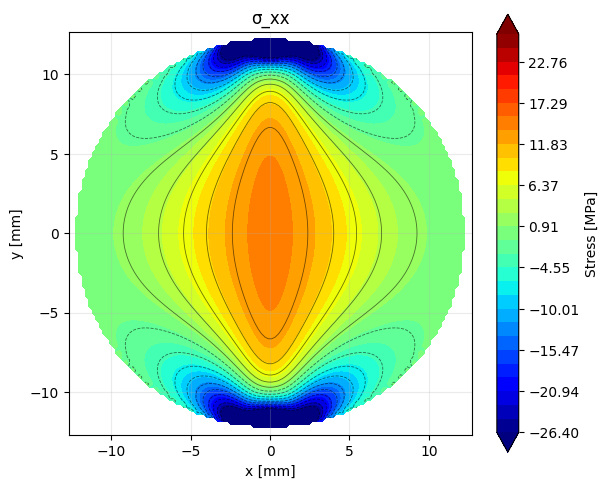

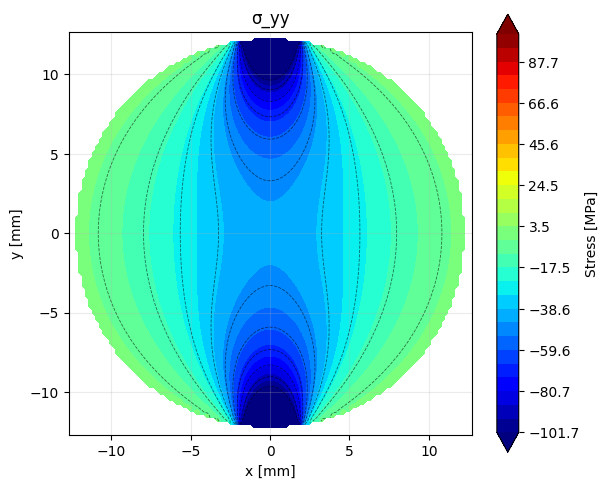

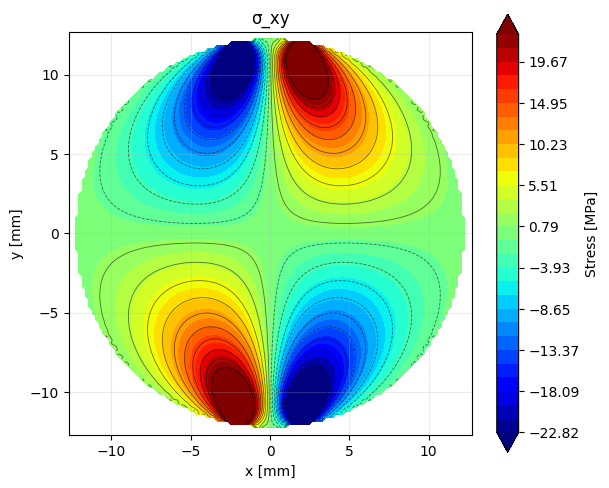


[outer-cycle] 1/4 method=iterative
[solve] start: cycle_00_initial (Nv=10, Ne=9)
[solve] done : cycle_00_initial


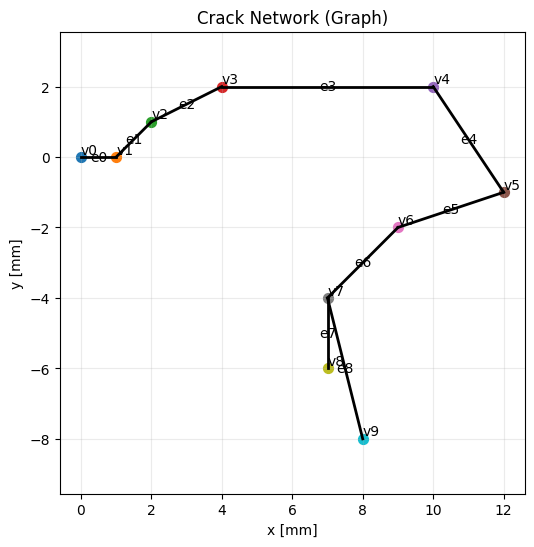

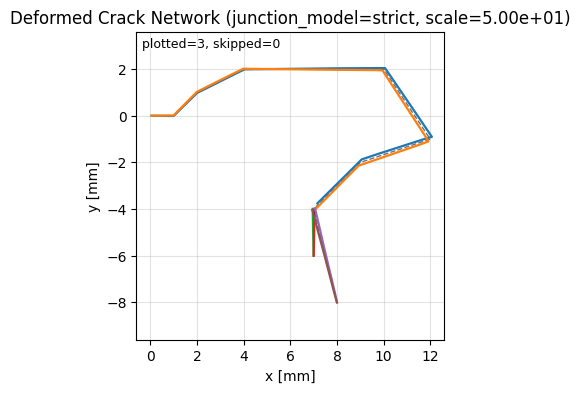

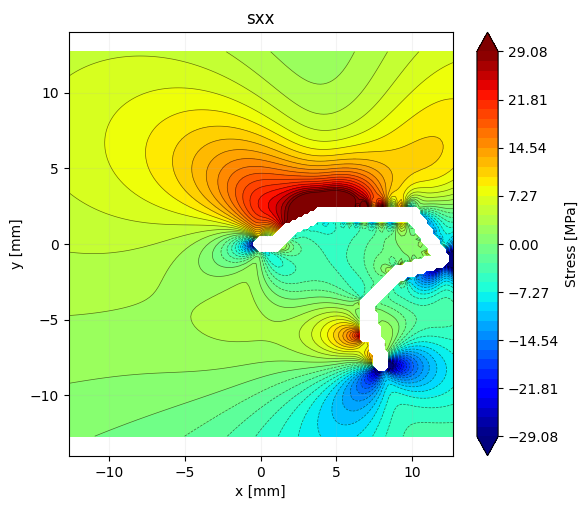

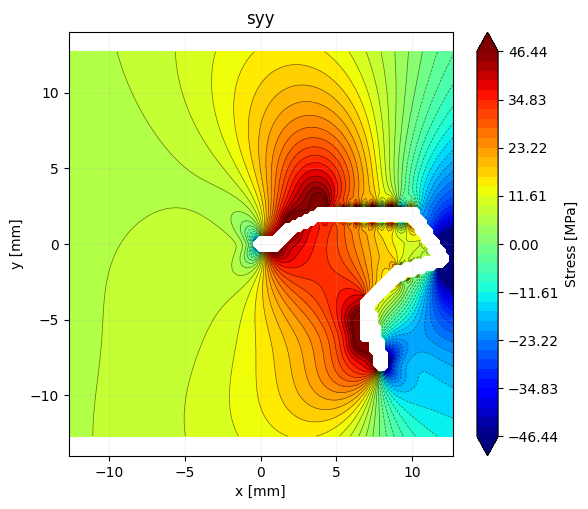

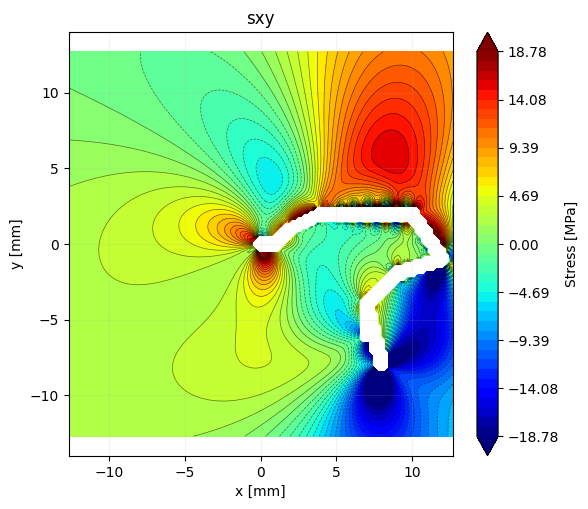

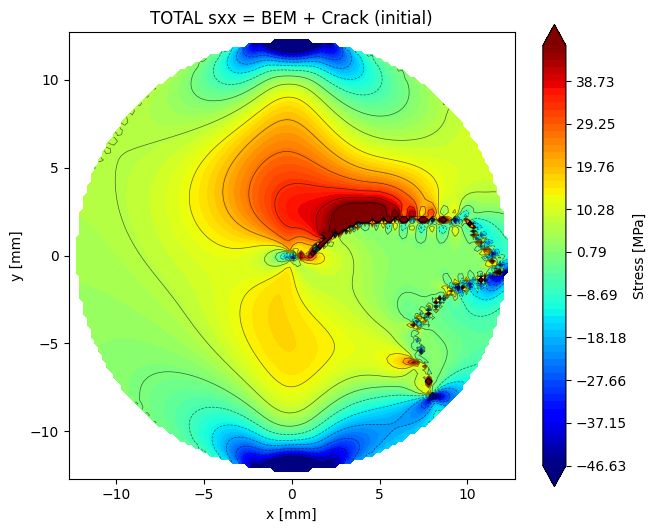

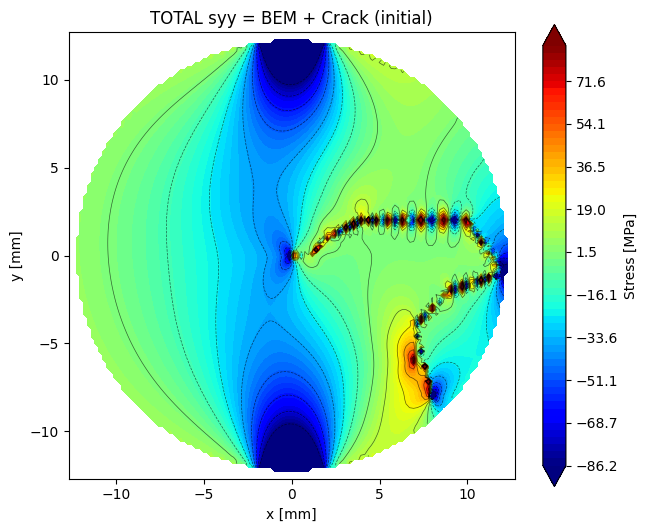

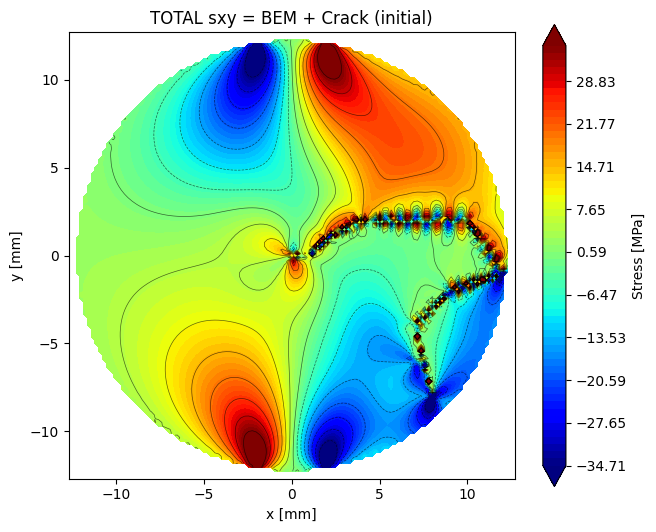

[solve] start: cycle_01_pre_simplify (Nv=16, Ne=15)
[solve] done : cycle_01_pre_simplify


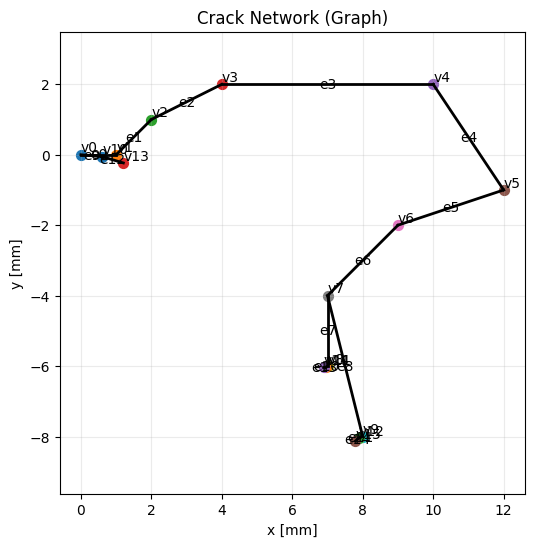

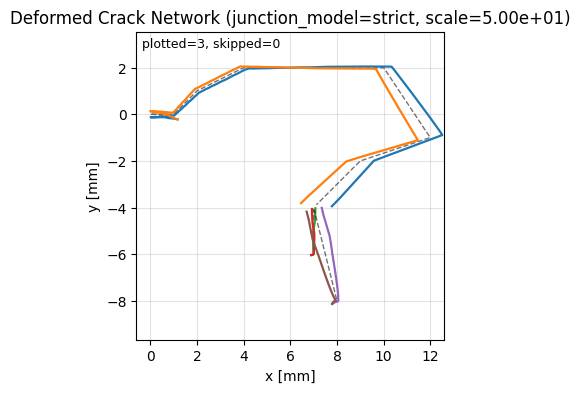

✓ Loaded network: 16 vertices, 15 edges
[solve] start: cycle_01_post_simplify (Nv=16, Ne=13)
[solve] done : cycle_01_post_simplify


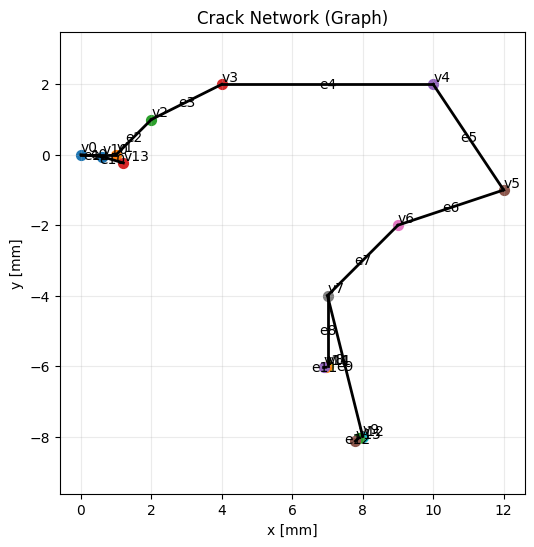

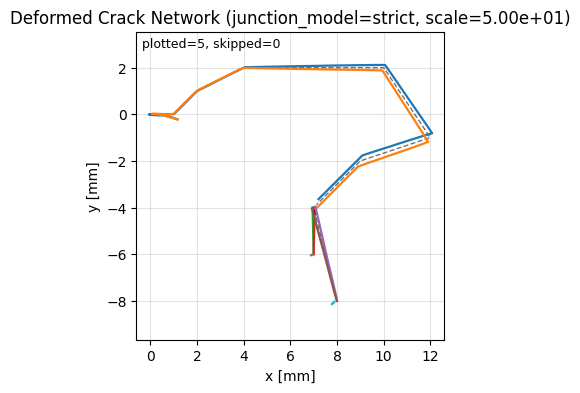

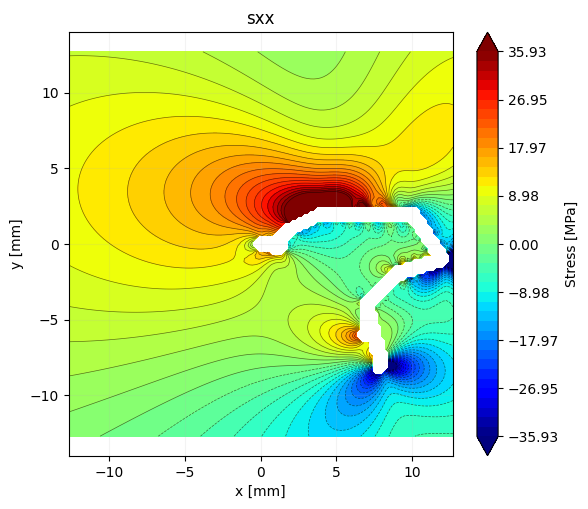

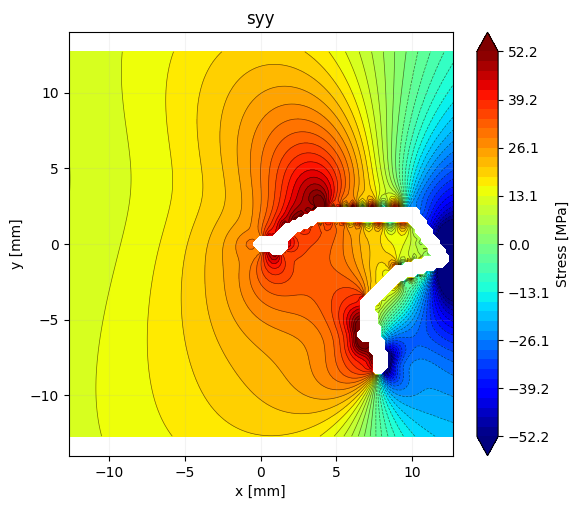

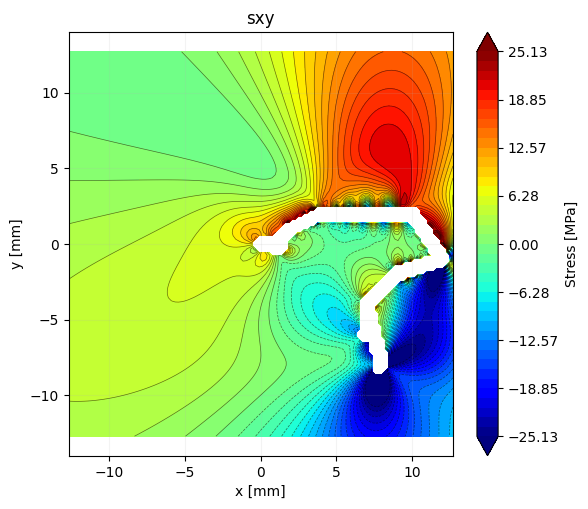

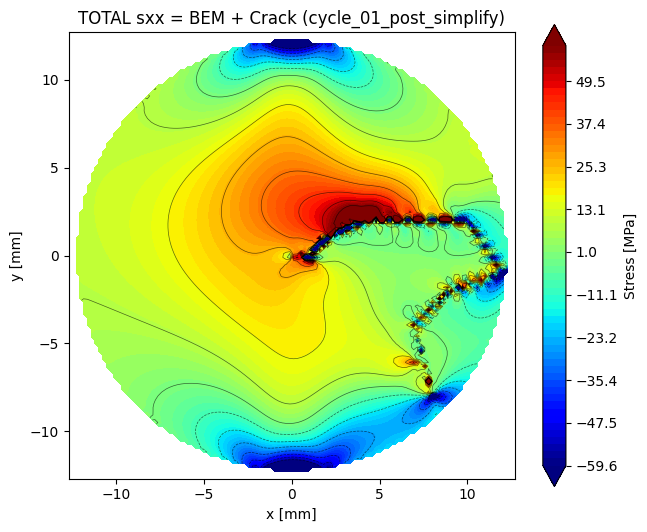

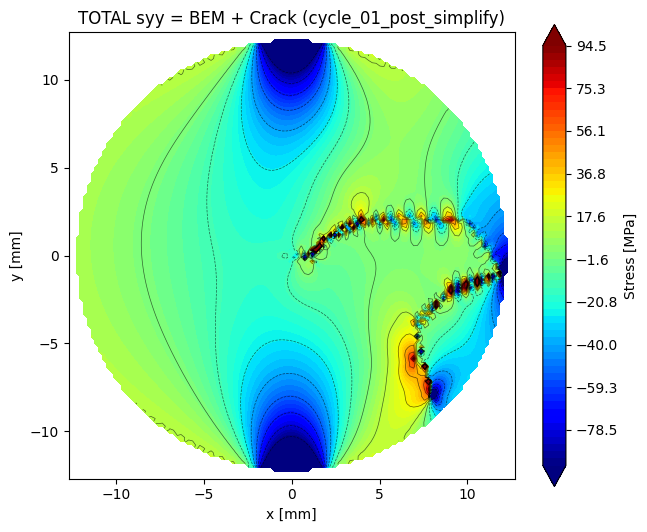

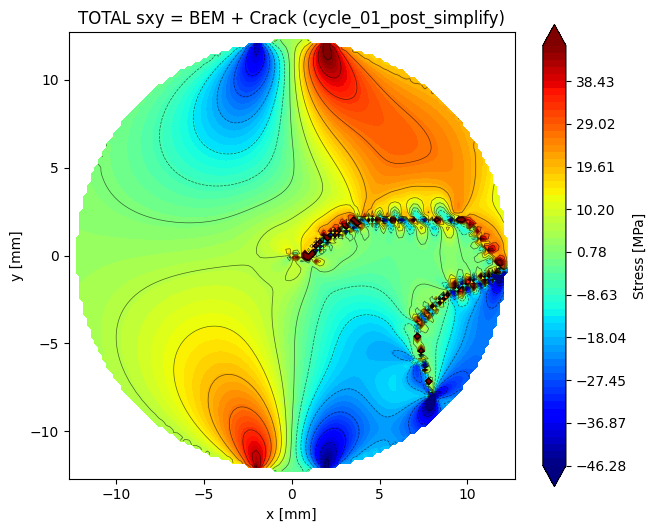

[solve] start: cycle_02_pre_simplify (Nv=23, Ne=20)
[solve] done : cycle_02_pre_simplify


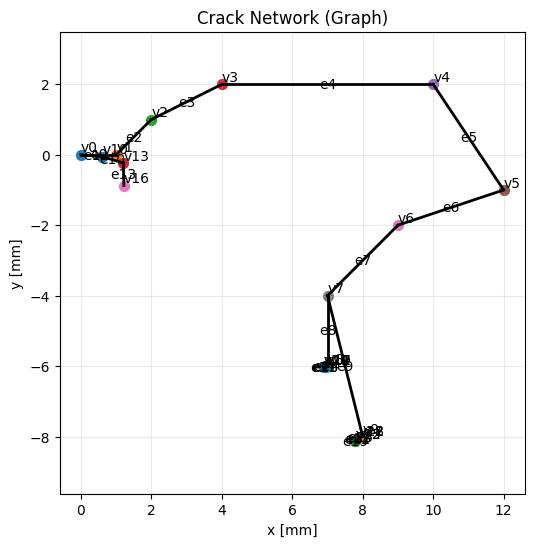

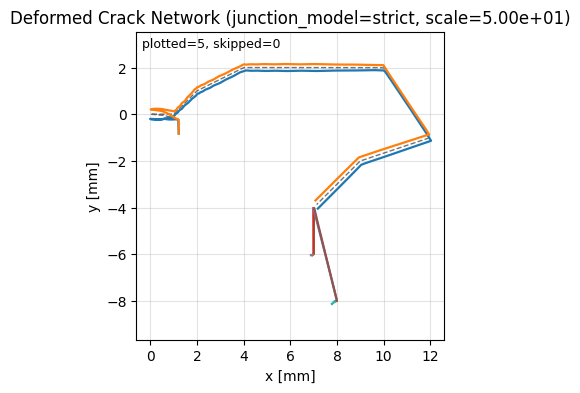

✓ Loaded network: 23 vertices, 20 edges
[solve] start: cycle_02_post_simplify (Nv=22, Ne=17)
[solve] done : cycle_02_post_simplify


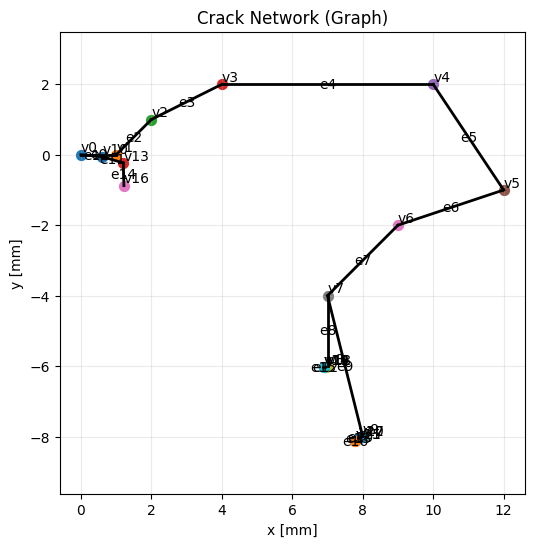

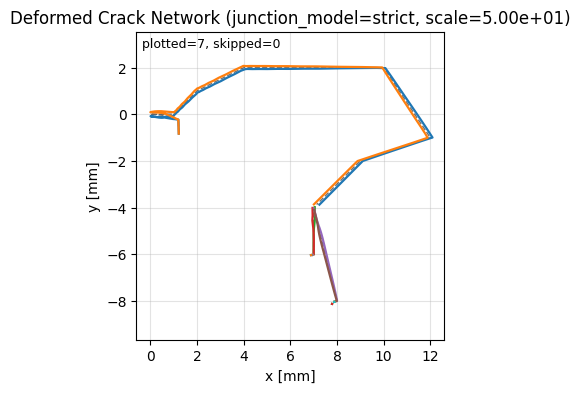

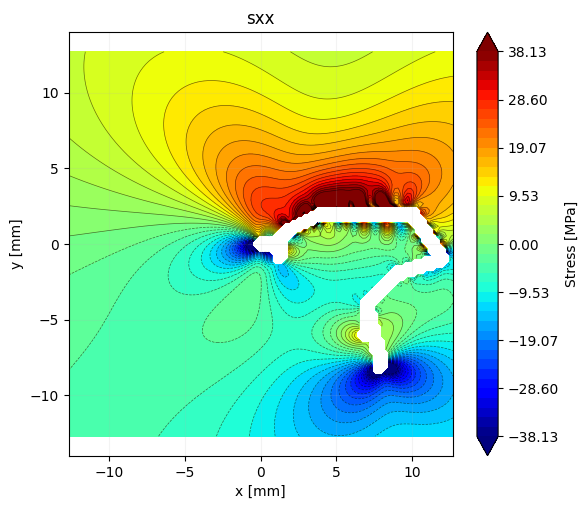

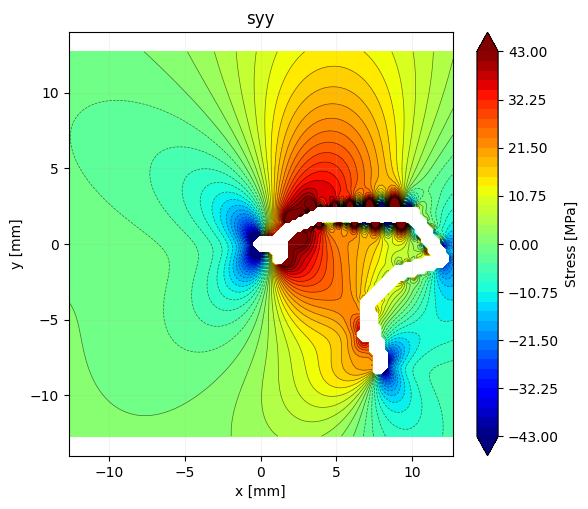

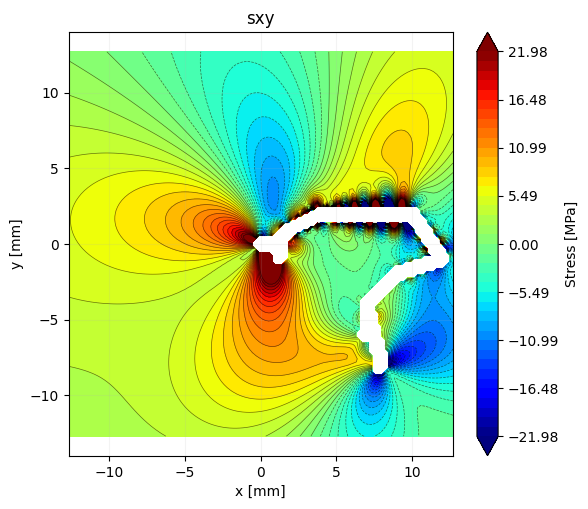

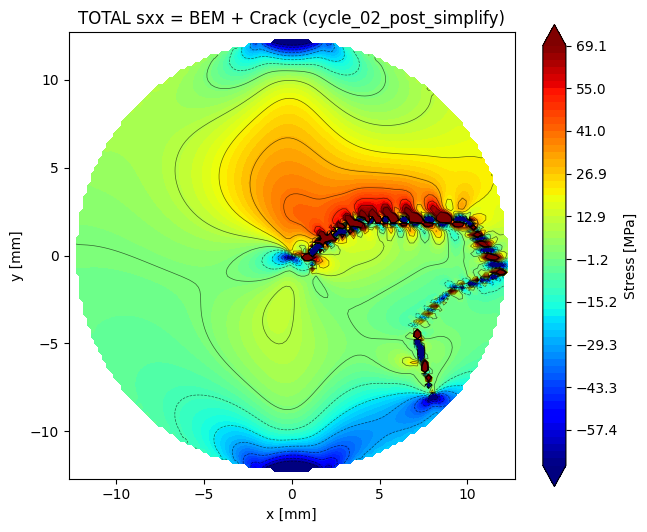

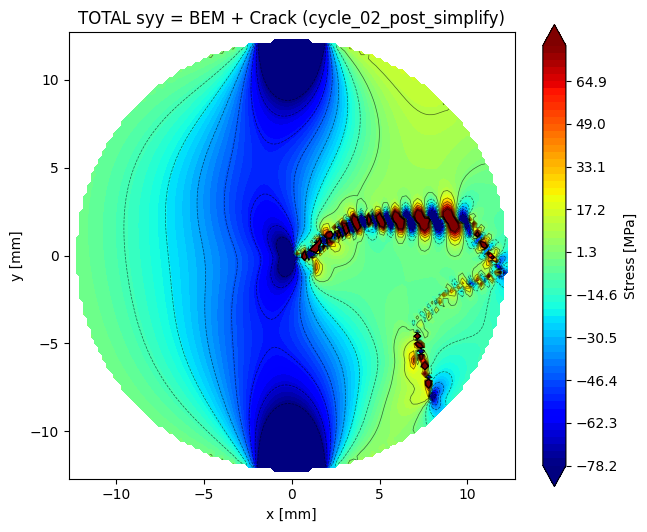

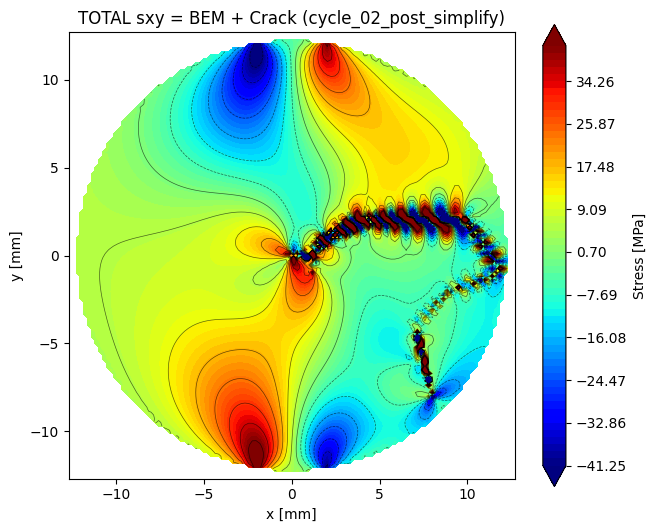

[solve] start: cycle_03_pre_simplify (Nv=30, Ne=25)
[solve] done : cycle_03_pre_simplify


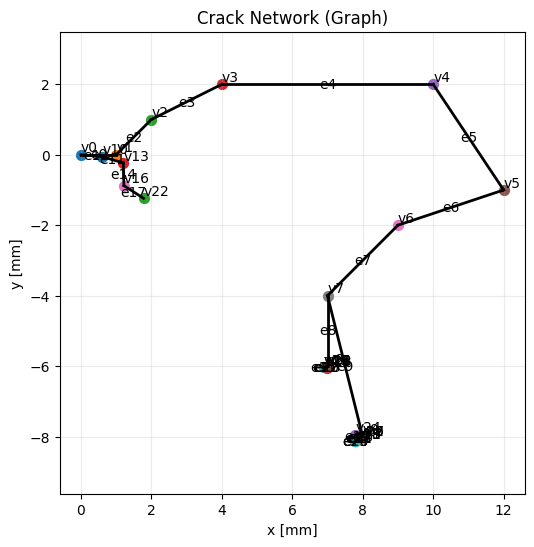

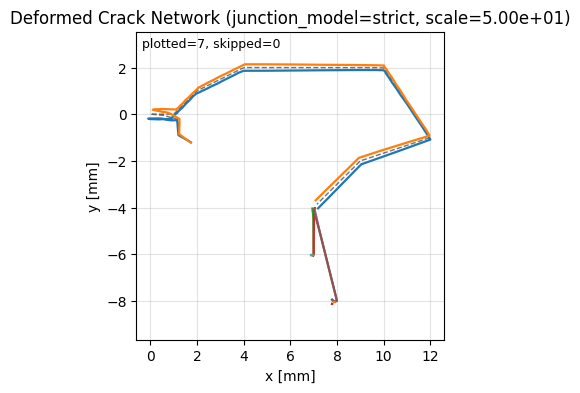

✓ Loaded network: 30 vertices, 25 edges
[solve] start: cycle_03_post_simplify (Nv=25, Ne=19)
[solve] done : cycle_03_post_simplify


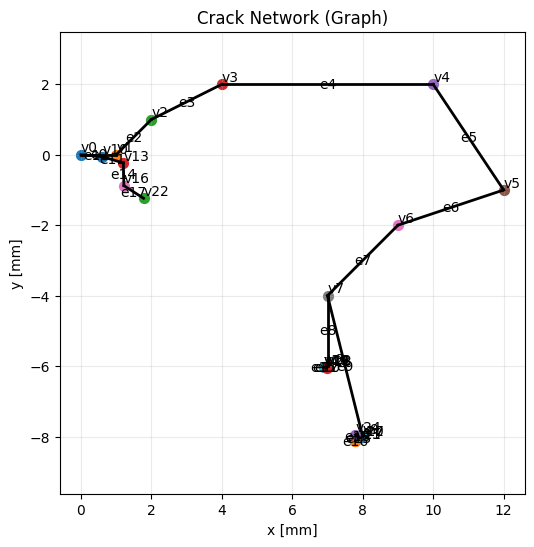

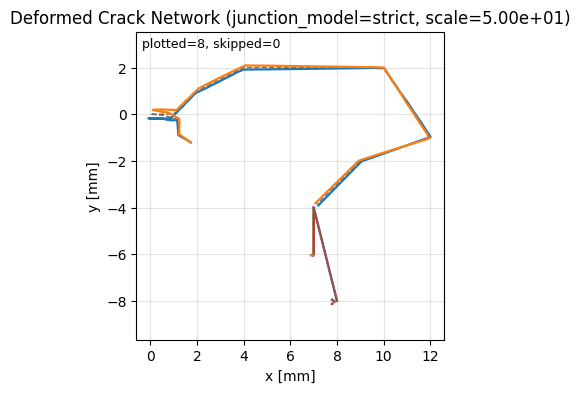

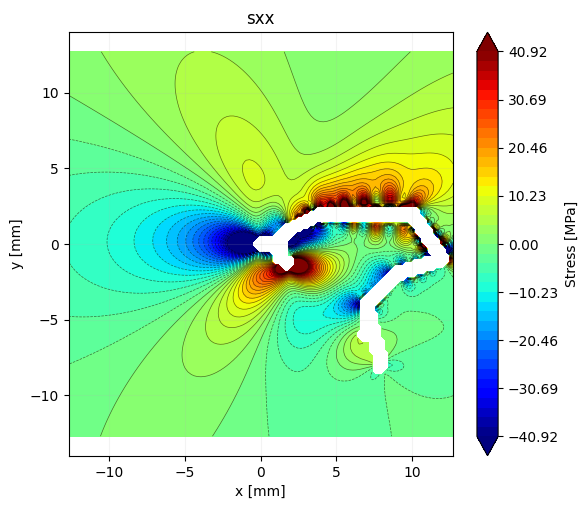

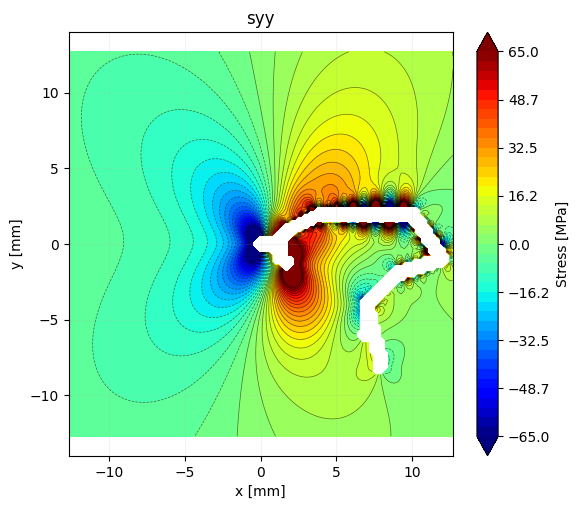

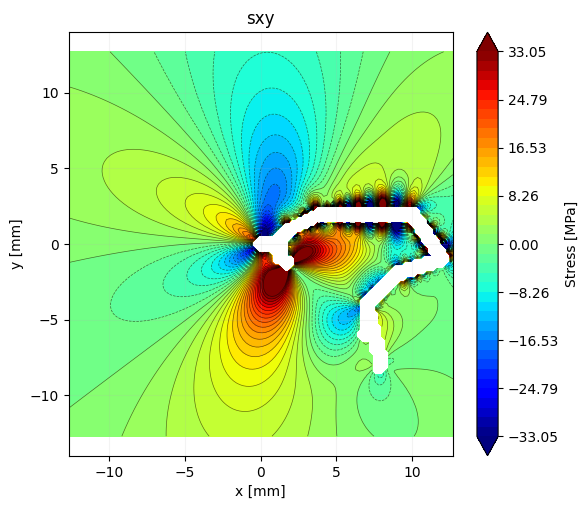

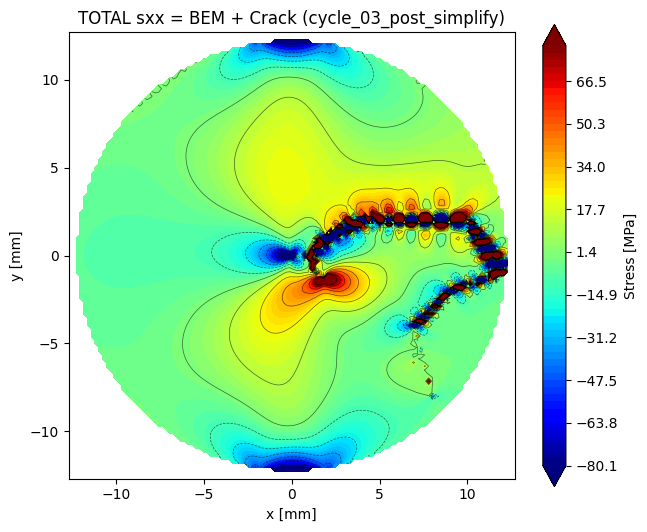

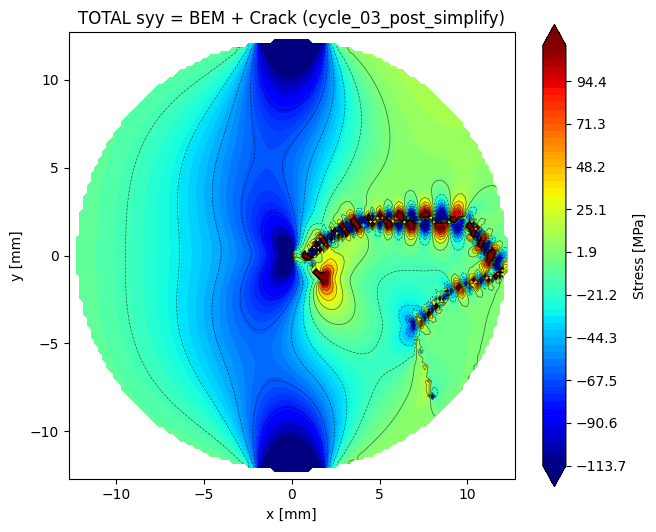

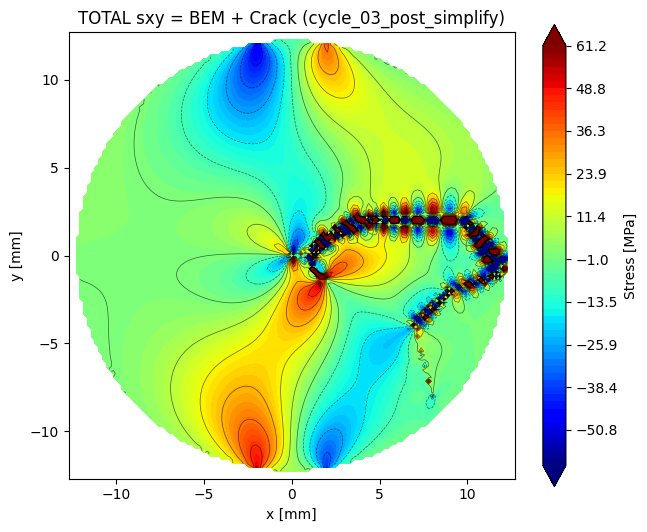

[solve] start: cycle_04_pre_simplify (Nv=30, Ne=24)
[solve] done : cycle_04_pre_simplify


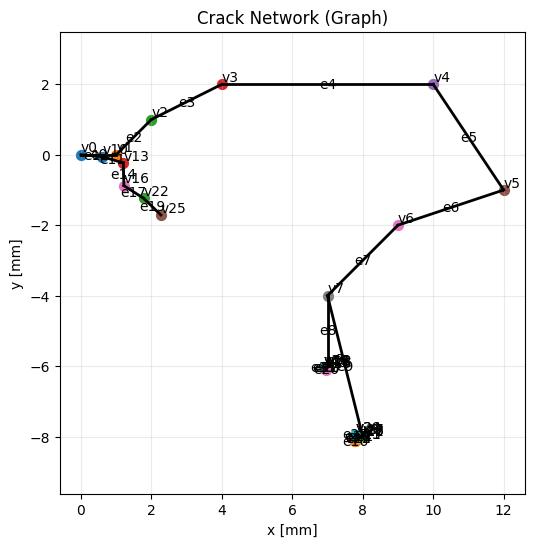

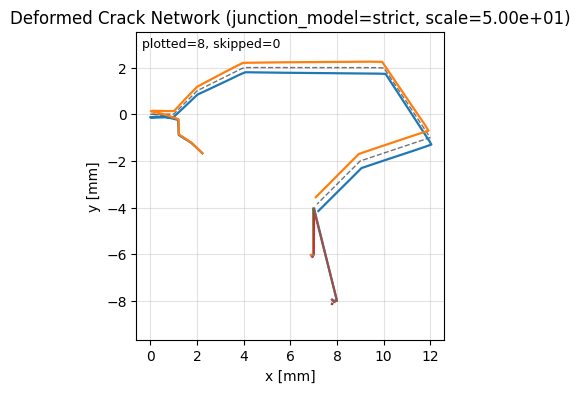

✓ Loaded network: 30 vertices, 24 edges
[solve] start: cycle_04_post_simplify (Nv=30, Ne=22)
[solve] done : cycle_04_post_simplify


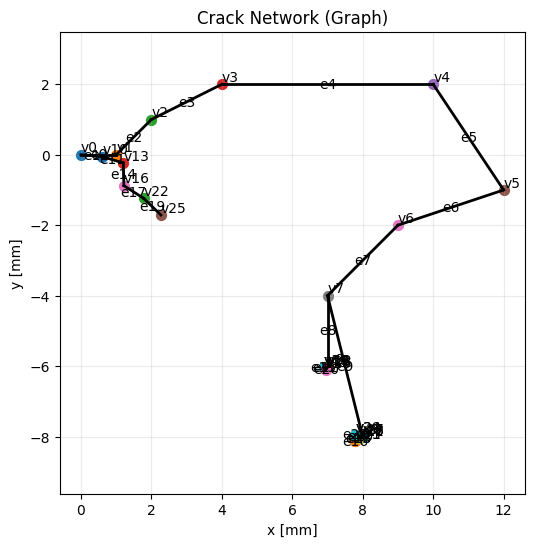

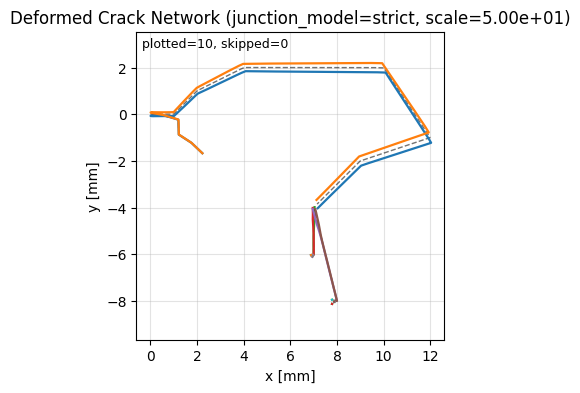

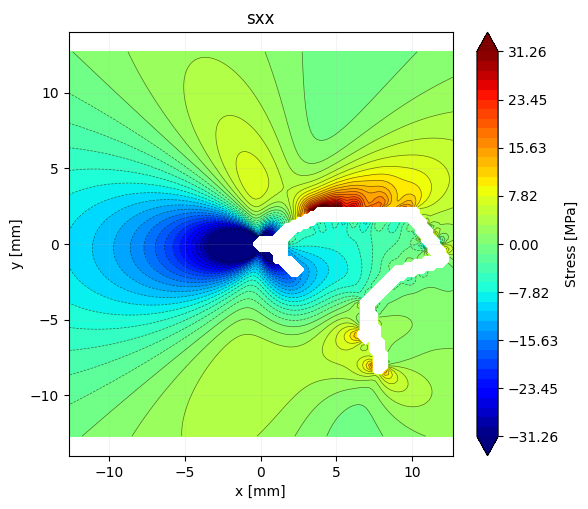

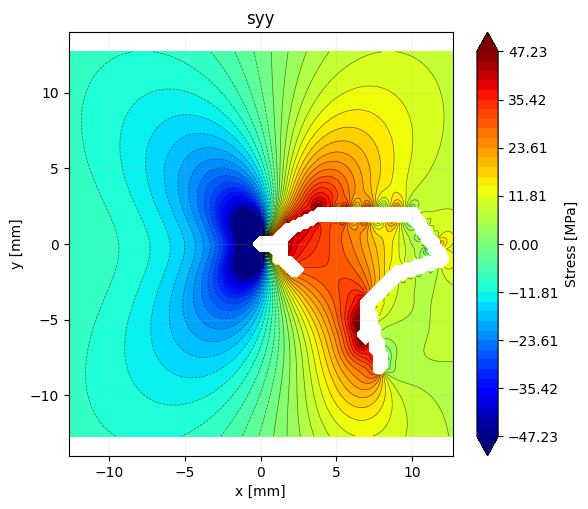

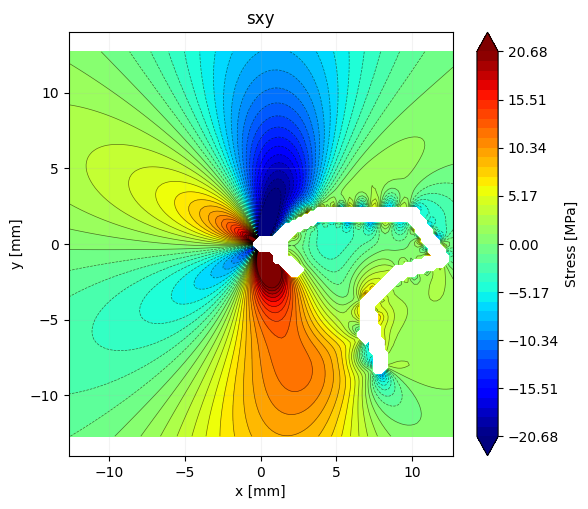

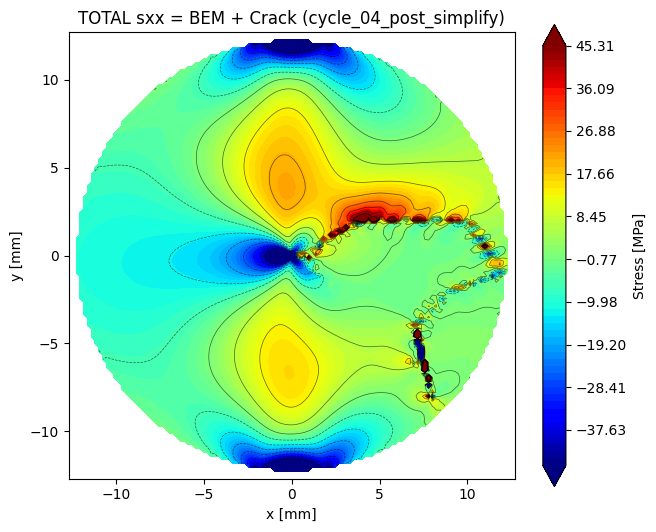

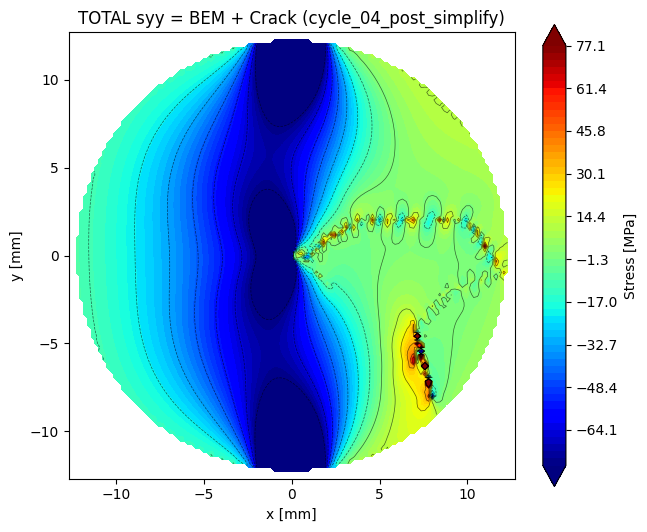

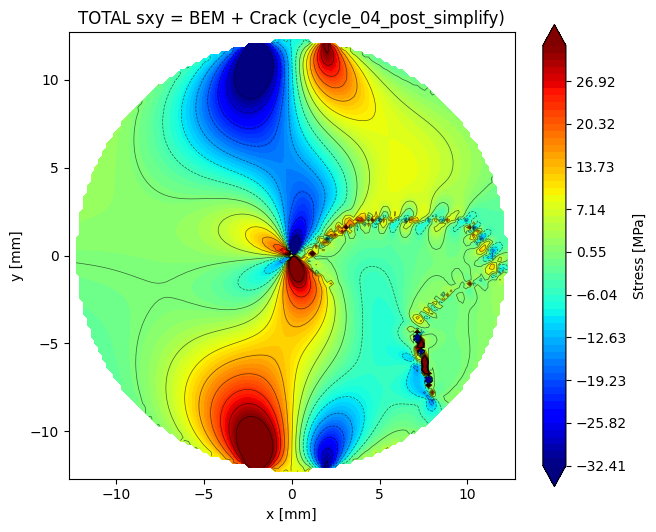

[solve] start: cycle_05_pre_simplify (Nv=43, Ne=35)
[solve] done : cycle_05_pre_simplify


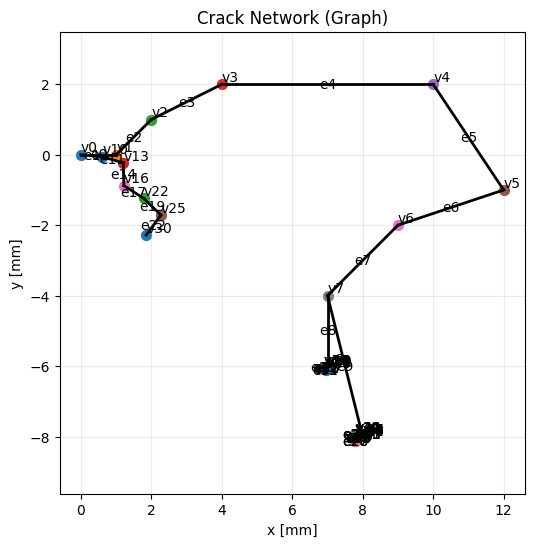

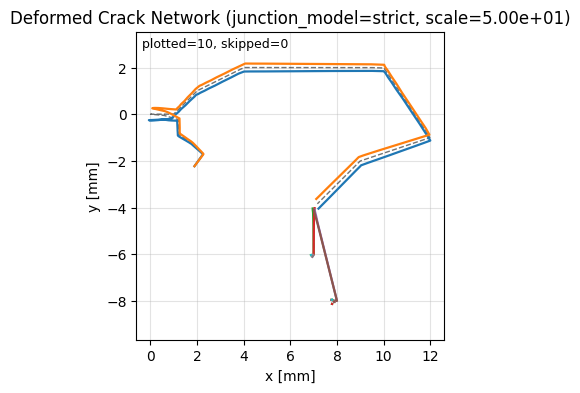

✓ Loaded network: 43 vertices, 35 edges
[solve] start: cycle_05_post_simplify (Nv=35, Ne=25)
[solve] done : cycle_05_post_simplify


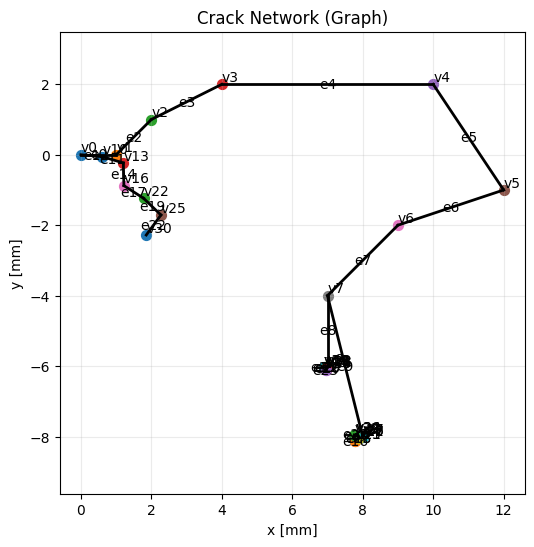

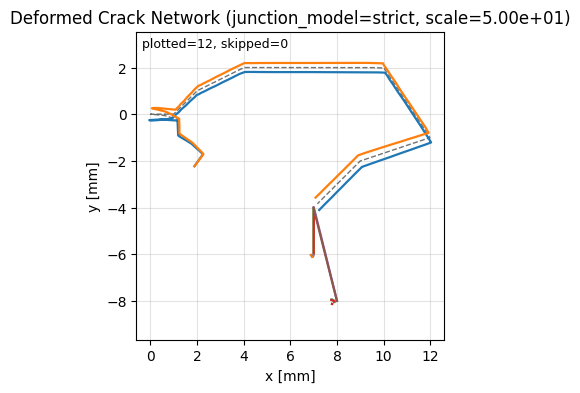

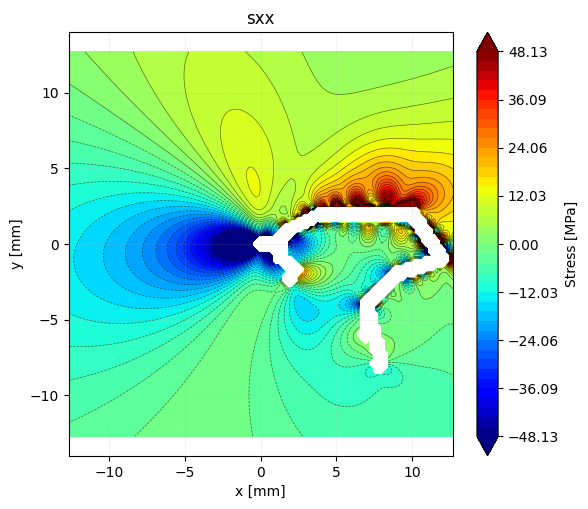

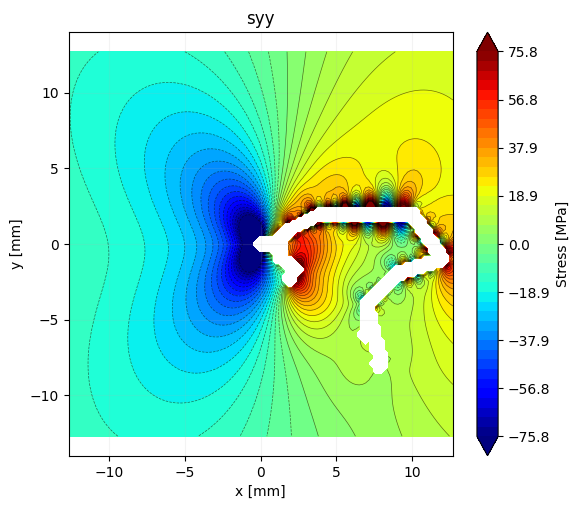

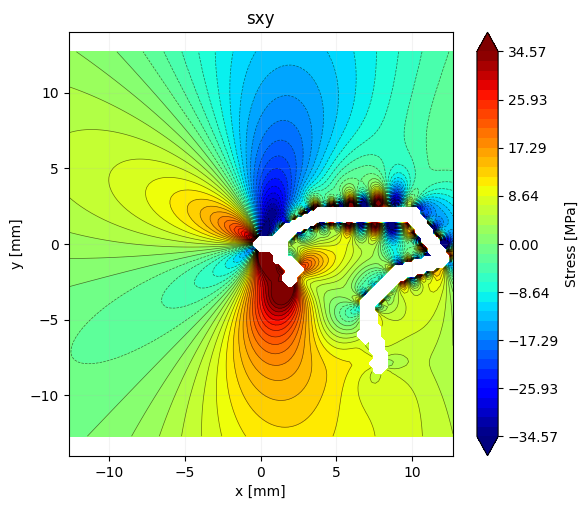

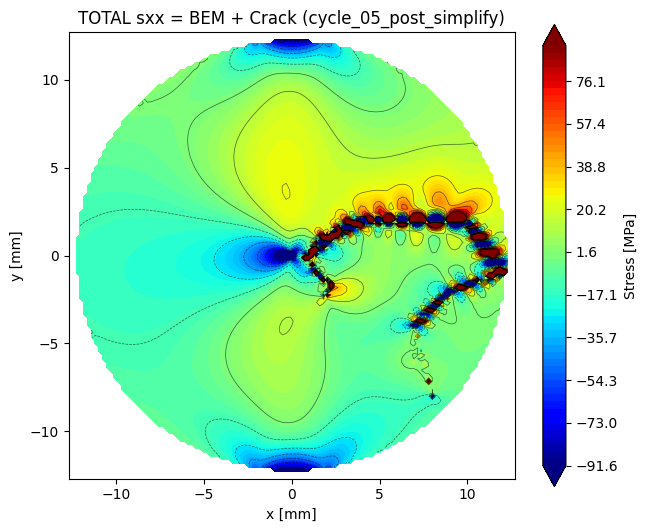

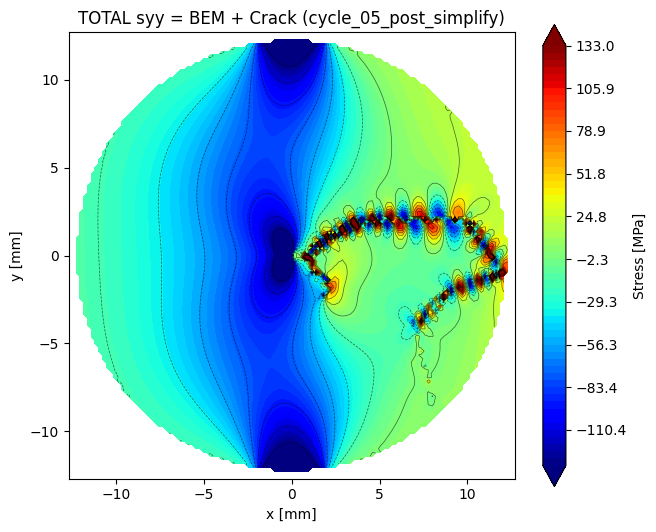

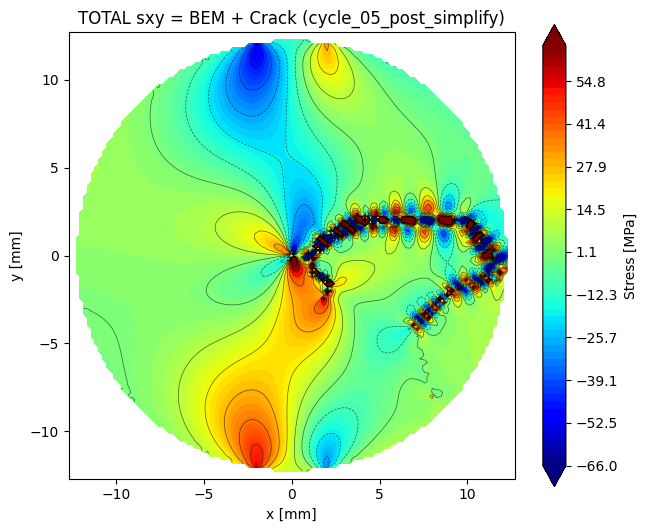

[solve] start: cycle_06_pre_simplify (Nv=38, Ne=28)
[solve] done : cycle_06_pre_simplify


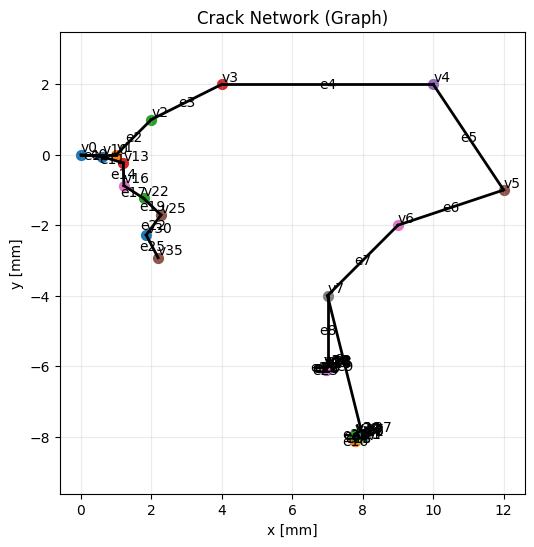

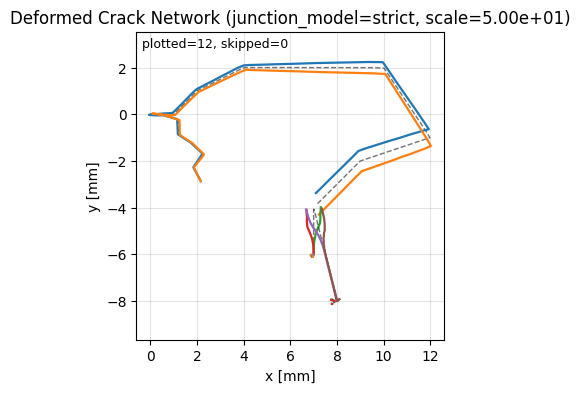

✓ Loaded network: 38 vertices, 28 edges
[solve] start: cycle_06_post_simplify (Nv=38, Ne=27)
[solve] done : cycle_06_post_simplify


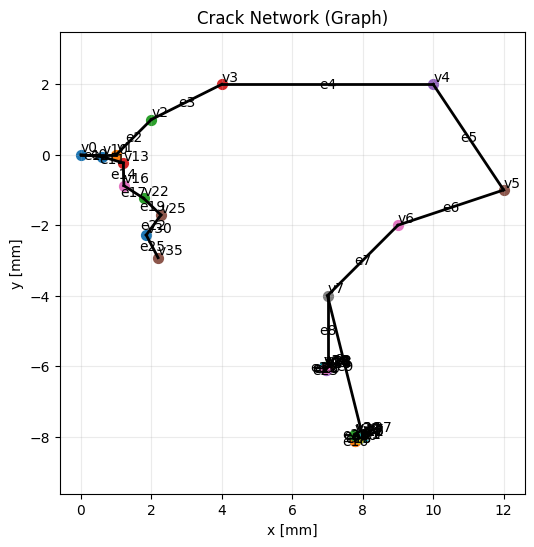

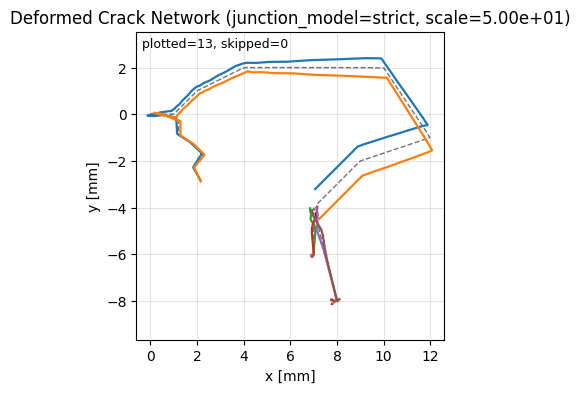

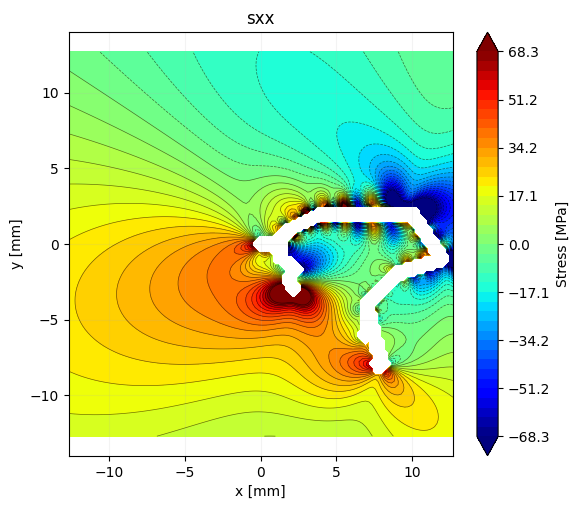

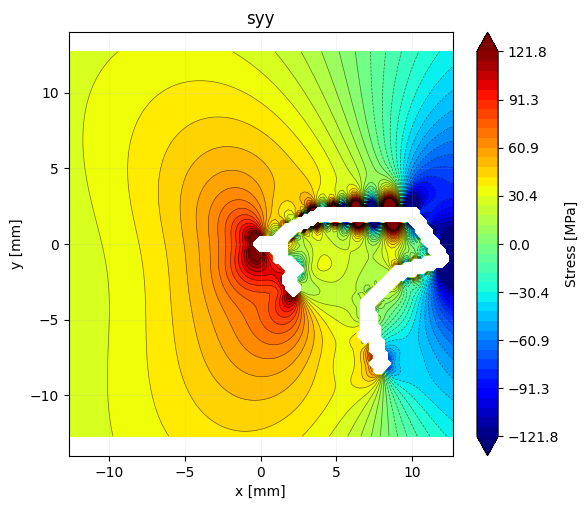

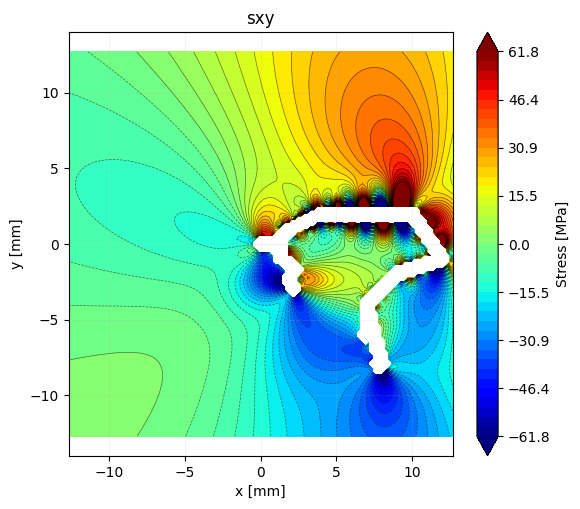

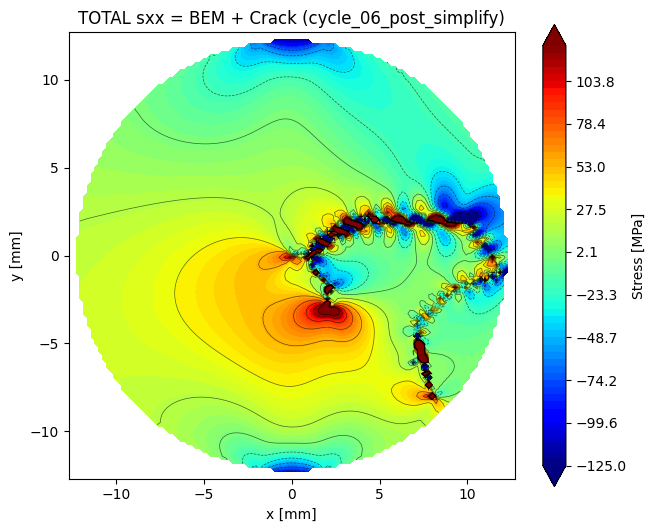

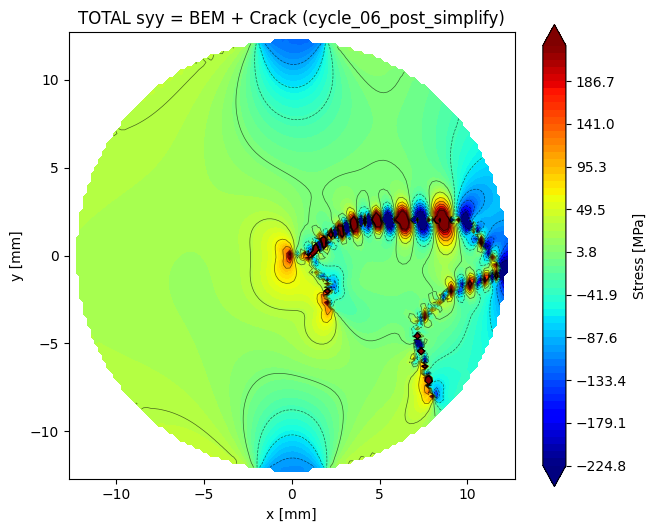

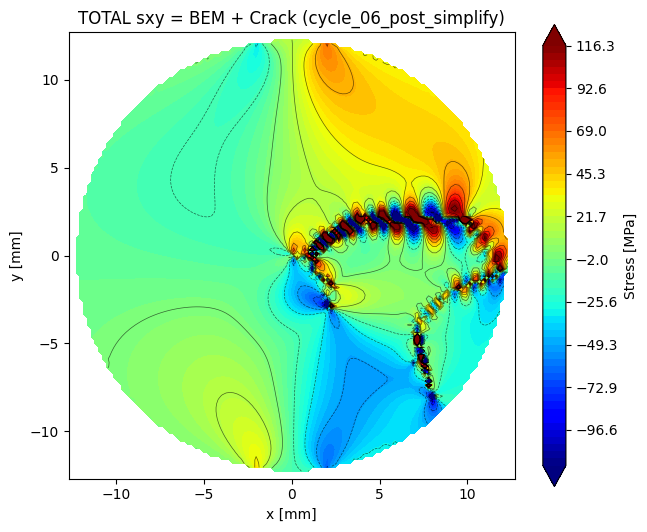

[solve] start: cycle_07_pre_simplify (Nv=57, Ne=46)
[solve] done : cycle_07_pre_simplify


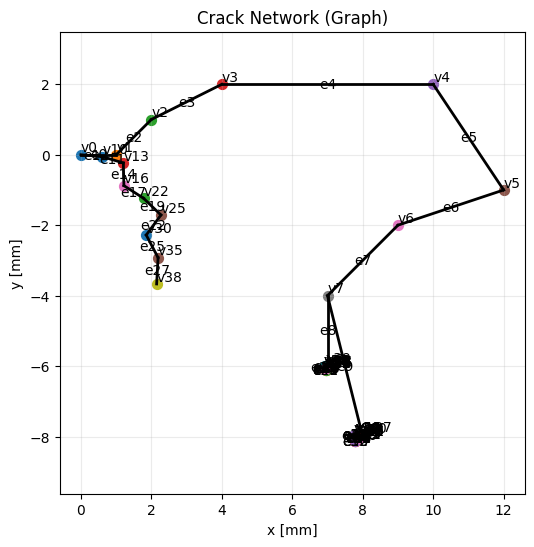

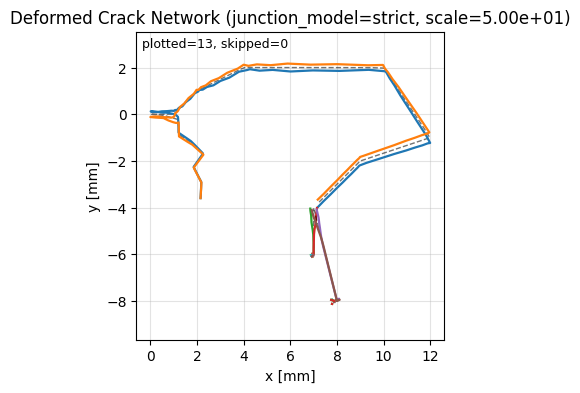

✓ Loaded network: 57 vertices, 46 edges
[solve] start: cycle_07_post_simplify (Nv=45, Ne=31)
[solve] done : cycle_07_post_simplify


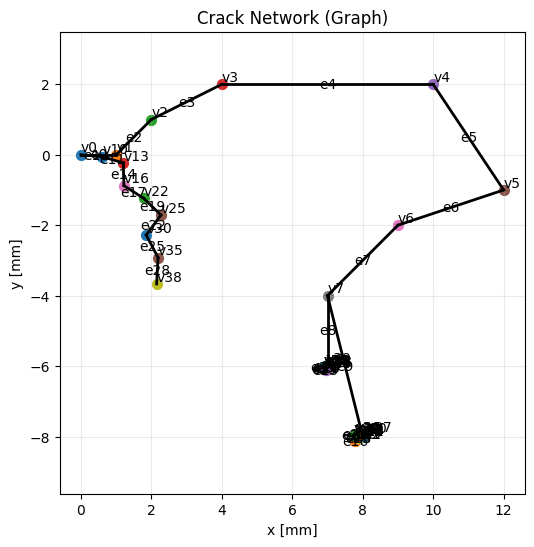

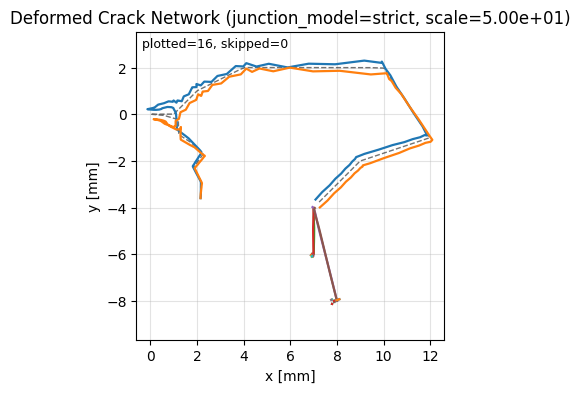

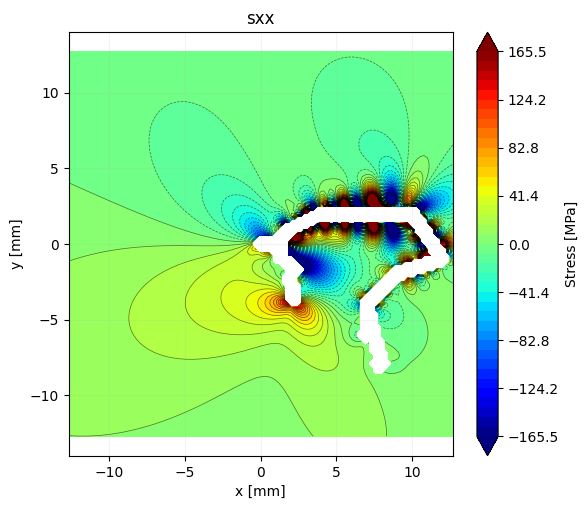

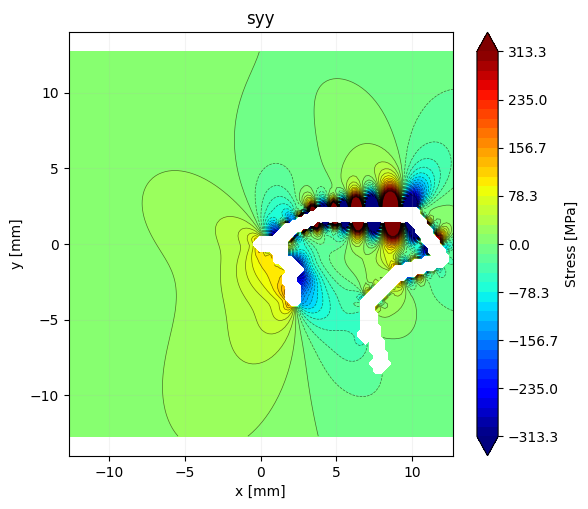

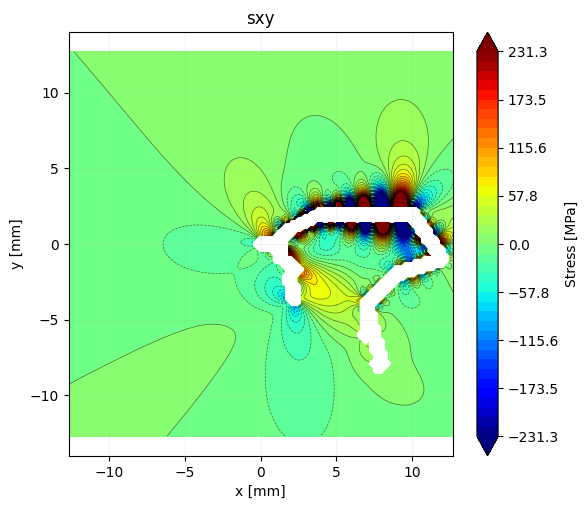

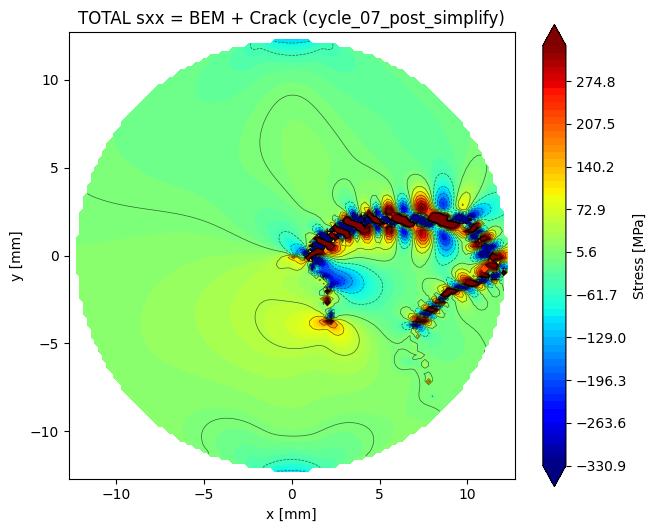

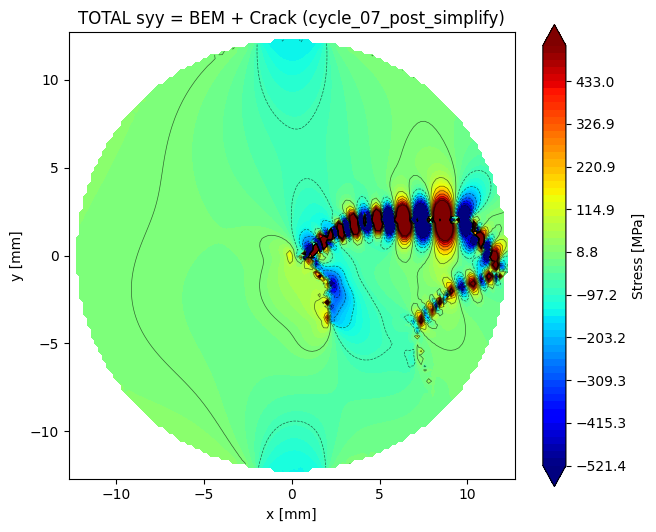

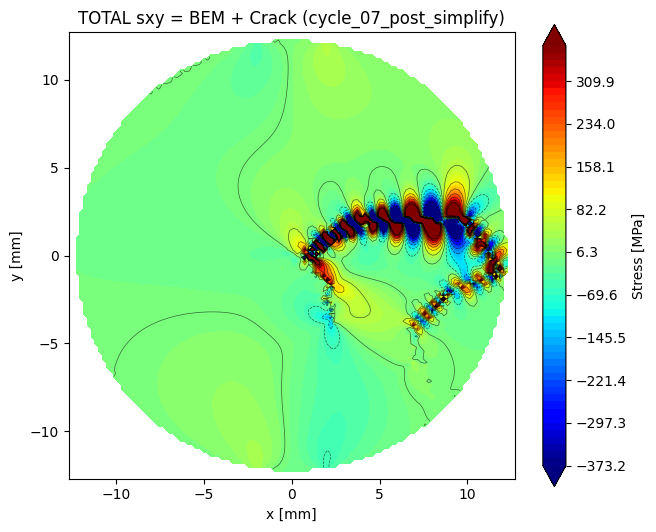

[solve] start: cycle_08_pre_simplify (Nv=62, Ne=48)
[solve] done : cycle_08_pre_simplify


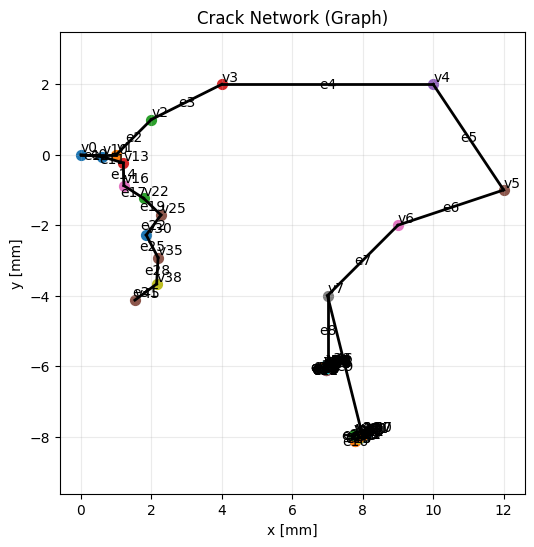

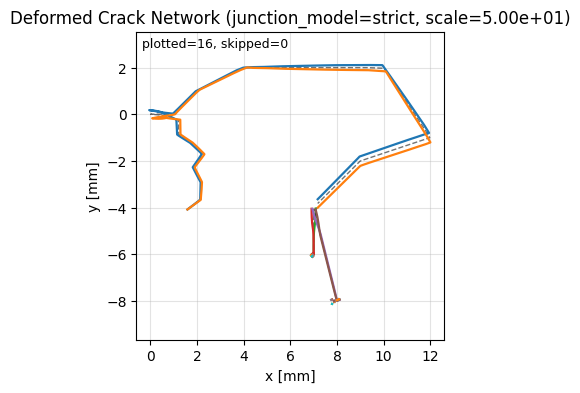

✓ Loaded network: 62 vertices, 48 edges
[solve] start: cycle_08_post_simplify (Nv=50, Ne=34)


KeyboardInterrupt: 

In [4]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime
import os
import sys
import json
import subprocess
from dataclasses import asdict, fields, MISSING

import numpy as np

# -----------------------
# Repo setup
# -----------------------
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from fracture_utils.Ubem.brazilian_disk_bem import BrazilianDiskParams, ensure_bem_field
from fracture_utils.Ubem.disk_network_propagation import CrackGrowthParams, run_network_growth_uncoupled
from fracture_utils.Ubem.disk_crack_plotting import PlotParams, make_standard_plot_hook, plot_total_field
from fracture_utils.Ubem.coupling_blocks_v2 import BEMBlockV2, compose_solver_kwargs_v2
from fracture_utils.Ubem.disk_iterative_coupling import (
    compute_crack_boundary_tractions_direct,
    solve_bem_with_extra_boundary_tractions,
)
from fracture_utils.Ubem.boundary_conditions import build_boundary


# =======================
# USER CONFIG (edit here)
# =======================

# Run control
COUPLING_METHOD = "iterative"   # "no_coupling" | "iterative" | "direct"
OUTER_CYCLES = 4
SKIP_BEM_SOLVE = True

# Initial network geometry
mm = 1e-3
# VERTICES = np.array([
#     [0, 0.0 * mm, -3.0 * mm],
#     [1, 0.0 * mm,  3.0 * mm],
# ], float)
# CONNECTIVITY = np.array([[0, 1]], int)
VERTICES = np.array([
    [0,   0.0*mm,  0.0*mm],   
    [1,  1.0*mm,  0.0*mm],   
    [2,  2.0*mm,  1*mm],   
    [3,  4.0*mm,  2*mm],   
    [4,  10.0*mm, 2.0*mm],
    [5,  12.0*mm, -1.0*mm],
    [6,  9.0*mm, -2*mm],
    [7,  7.0*mm, -4.0*mm],
    [8,  7.0*mm, -6.0*mm],
    [9, 8.0*mm, -8.0*mm]
], dtype=float)

CONNECTIVITY = np.array([
    [0, 1],   # e0
    [1, 2],   # e1
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6],
    [6, 7],
    [7, 8],
    [7, 9],
], dtype=int)

# Disk/BEM params (start from module defaults, set explicit current values)
DISK_PARAMS = dict(
    R=25.4e-3 / 2,
    P_total=3.8e3,
    E=231.52e9,
    nu=0.3,
    n_elem=120,
    gauss_n=6,
    plane_strain=True,
    arc_half_angle_deg=10.0,
    h=6.35e-3,
    n_grid=120,
    pad_frac=0.03,
)

# BEM baseline compute/load behavior
BEM_FIELD_CONFIG = dict(
    show=True,
    save_contours=True,
)

# Plot config
PLOT_PARAMS = dict(
    cmap="jet",
    n_bands=40,
    vmax_factor=2.0,
    dpi=300,
    match_limits_to_crack=True,
    robust=True,
    robust_pct=97.0,
    symmetric=True,
    n_levels=60,
    n_line_levels=15,
    fixed_vlim_mpa=None,
    augmented_correction_stride=4,
)

HOOK_CONFIG = dict(
    show_initial=True,
    show_cycles=True,
    show_final=True,
    only_post_simplify=True,
)

# Solver kwargs exposed (defaults from run_network_growth_uncoupled)
SOLVER_KWARGS_DEFAULTS = dict(
    ne_half=60,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=9,
    nq_stress=12,
    crack_mode="half",
    junction_model="core",
)

# One-way run solver kwargs (editable)
ONE_WAY_SOLVER_KWARGS = dict(SOLVER_KWARGS_DEFAULTS)

# Growth / propagation params (including newly used simplification_config)
GROWTH_PARAMS = dict(
    material_E=200e9,
    material_nu=0.30,
    plane_stress=False,
    f0=0.03,
    f_fixed=0.03,
    step_mode="fixed_step",
    simultaneous_tip_growth=True,
    Kc_demo=1e5,
    rmax_frac=0.25,
    min_pts=8,
    max_cycles=8,
    vertex_high=16,
    L_limit_mm=20.0,
    simplification_config=None,   # e.g. {"max_angle_deviation": 2.0, ...}
)

# Direct KKT payload + solver knobs (used only when COUPLING_METHOD == "direct")
AUGMENTED_CONFIG = dict(
    d_mode="correction_zero",
    payload_gauss_n=4,
    augmented_enforce_crack_equilibrium=True,
    augmented_equilibrate=True,
    augmented_equilibrate_cols=False,
    augmented_physical_scaling=True,
    augmented_scale_traction_rows=True,
    augmented_ridge_q=1e-4,
    augmented_ridge_y=1e-8,
    augmented_keep_bem_applied=True,
)

# Iterative BEM update controls
ITERATIVE_UPDATE_CONFIG = dict(
    show=False,
    gauss_n=None,   # None => disk.gauss_n
)


# =======================
# Utilities
# =======================

def _git_short_hash(default="nogit"):
    try:
        out = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], cwd=repo_root)
        return out.decode("utf-8", errors="ignore").strip() or default
    except Exception:
        return default


def _run_id():
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    return f"{ts}_{_git_short_hash()}"


def _network_to_arrays(net):
    V = np.array([[int(v.id), float(v.x), float(v.y)] for v in net.vertices], float)
    C = np.array([[int(e.v0), int(e.v1)] for e in net.edges], int) if len(net.edges) else np.zeros((0, 2), int)
    return V, C


def _save_total_as_bem_arrays(bem_dir: Path, Sxx_tot, Syy_tot, Sxy_tot):
    xs = np.load(bem_dir / "xs.npy")
    ys = np.load(bem_dir / "ys.npy")
    np.save(bem_dir / "xs.npy", xs)
    np.save(bem_dir / "ys.npy", ys)
    np.save(bem_dir / "Sxx.npy", np.asarray(Sxx_tot, float))
    np.save(bem_dir / "Syy.npy", np.asarray(Syy_tot, float))
    np.save(bem_dir / "Sxy.npy", np.asarray(Sxy_tot, float))


def _dataclass_defaults(dc_type):
    d = {}
    for f in fields(dc_type):
        if f.default is not MISSING:
            d[f.name] = f.default
        elif f.default_factory is not MISSING:  # type: ignore[attr-defined]
            d[f.name] = f.default_factory()      # type: ignore[misc]
        else:
            d[f.name] = None
    return d


def _fmt(v):
    if isinstance(v, np.ndarray):
        return np.array2string(v, separator=", ")
    if isinstance(v, (list, tuple, dict)):
        try:
            return json.dumps(v, ensure_ascii=False)
        except Exception:
            return str(v)
    return str(v)


def _write_provenance(run_dir: Path, run_id: str, table_rows):
    prov = run_dir / f"provenance_{run_id}.md"
    lines = []
    lines.append(f"# Provenance - {run_id}\n")
    lines.append("")
    lines.append(f"- Generated: {datetime.now().isoformat()}\n")
    lines.append(f"- Repo root: `{repo_root}`\n")
    lines.append(f"- Notebook: `VCM_3_2/notebooks/disk_experiments.ipynb`\n")
    lines.append("")
    lines.append("## Run Configuration\n")
    lines.append("")
    lines.append("| Group | Parameter | Default | Effective | Source |\n")
    lines.append("|---|---|---|---|---|\n")
    for g, p, d, e, s in table_rows:
        lines.append(f"| {g} | `{p}` | `{_fmt(d)}` | `{_fmt(e)}` | {s} |\n")
    prov.write_text("".join(lines), encoding="utf-8")


def _write_provenance_json(run_dir: Path, run_id: str, table_rows):
    prov_json = run_dir / f"provenance_{run_id}.json"
    rows = []
    for g, p, d, e, s in table_rows:
        rows.append({
            "group": g,
            "parameter": p,
            "default": d,
            "effective": e,
            "source": s,
        })
    payload = {
        "run_id": run_id,
        "generated_at": datetime.now().isoformat(),
        "repo_root": str(repo_root),
        "notebook": "VCM_3_2/notebooks/disk_experiments.ipynb",
        "rows": rows,
    }

    def _json_default(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, (np.floating, np.integer)):
            return obj.item()
        return str(obj)

    prov_json.write_text(json.dumps(payload, ensure_ascii=False, indent=2, default=_json_default), encoding="utf-8")


# =======================
# Build run directories
# =======================
run_id = _run_id()
run_dir = repo_root / "output" / "disk_experiments" / run_id
run_dir.mkdir(parents=True, exist_ok=True)
print(f"[run_id] {run_id}")
print(f"[run_dir] {run_dir}")


# =======================
# Instantiate config objects
# =======================
disk = BrazilianDiskParams(**DISK_PARAMS)
plot_params = PlotParams(**PLOT_PARAMS)

boundary_mesh = build_boundary({
    "type": "circle",
    "R": disk.R,
    "n_boundary": disk.n_elem,
    "center": (0.0, 0.0),
})

bem_block = BEMBlockV2(disk=disk, out_dir=run_dir)
one_way_kwargs = compose_solver_kwargs_v2("one_way", base_solver_kwargs=ONE_WAY_SOLVER_KWARGS)

aug_payload = bem_block.build_augmented_payload(
    d_mode=AUGMENTED_CONFIG["d_mode"],
    gauss_n=AUGMENTED_CONFIG["payload_gauss_n"],
)
direct_kwargs = compose_solver_kwargs_v2(
    "full_kkt",
    base_solver_kwargs={
        "augmented_enforce_crack_equilibrium": AUGMENTED_CONFIG["augmented_enforce_crack_equilibrium"],
        "augmented_equilibrate": AUGMENTED_CONFIG["augmented_equilibrate"],
        "augmented_equilibrate_cols": AUGMENTED_CONFIG["augmented_equilibrate_cols"],
        "augmented_physical_scaling": AUGMENTED_CONFIG["augmented_physical_scaling"],
        "augmented_scale_traction_rows": AUGMENTED_CONFIG["augmented_scale_traction_rows"],
    },
    augmented_payload=aug_payload,
    augmented_ridge_q=AUGMENTED_CONFIG["augmented_ridge_q"],
    augmented_ridge_y=AUGMENTED_CONFIG["augmented_ridge_y"],
    augmented_keep_bem_applied=AUGMENTED_CONFIG["augmented_keep_bem_applied"],
)

hook = make_standard_plot_hook(
    bem_dir=run_dir,
    combined_out_dir=run_dir,
    plot_params=plot_params,
    show_initial=HOOK_CONFIG["show_initial"],
    show_cycles=HOOK_CONFIG["show_cycles"],
    show_final=HOOK_CONFIG["show_final"],
    only_post_simplify=HOOK_CONFIG["only_post_simplify"],
)


# =======================
# Provenance table rows
# =======================
rows = []

# Run control
rows += [
    ("run", "COUPLING_METHOD", "iterative", COUPLING_METHOD, "notebook"),
    ("run", "OUTER_CYCLES", 5, OUTER_CYCLES, "notebook"),
    ("run", "SKIP_BEM_SOLVE", True, SKIP_BEM_SOLVE, "notebook"),
]

# Network
rows += [
    ("network", "mm", 1e-3, mm, "notebook"),
    ("network", "vertices", "(current in source)", VERTICES, "notebook"),
    ("network", "connectivity", "(current in source)", CONNECTIVITY, "notebook"),
]

# Disk params defaults vs effective
disk_defaults = _dataclass_defaults(BrazilianDiskParams)
for k, v in asdict(disk).items():
    rows.append(("disk", k, disk_defaults.get(k), v, "notebook/default"))

# BEM field controls
rows += [
    ("bem_field", "recompute", False, (not SKIP_BEM_SOLVE), "derived"),
    ("bem_field", "show", True, BEM_FIELD_CONFIG["show"], "notebook"),
    ("bem_field", "save_contours", True, BEM_FIELD_CONFIG["save_contours"], "notebook"),
]

# Plot params defaults vs effective
plot_defaults = PlotParams().__dict__.copy()
for k, v in plot_params.__dict__.items():
    rows.append(("plot", k, plot_defaults.get(k), v, "notebook/default"))
for k, v in HOOK_CONFIG.items():
    hook_default = dict(show_initial=True, show_cycles=False, show_final=True, only_post_simplify=True).get(k)
    rows.append(("plot_hook", k, hook_default, v, "notebook/default"))

# Solver kwargs
for k, v in SOLVER_KWARGS_DEFAULTS.items():
    rows.append(("solver_kwargs", k, v, ONE_WAY_SOLVER_KWARGS.get(k, v), "notebook/default"))

# Growth params
growth_defaults = _dataclass_defaults(CrackGrowthParams)
for k, v in GROWTH_PARAMS.items():
    rows.append(("growth", k, growth_defaults.get(k), v, "notebook/default"))

# Direct / augmented
rows += [
    ("augmented", "d_mode", "correction_zero", AUGMENTED_CONFIG["d_mode"], "notebook/default"),
    ("augmented", "payload_gauss_n", 4, AUGMENTED_CONFIG["payload_gauss_n"], "notebook/default"),
    ("augmented", "augmented_ridge_q", 1e-4, AUGMENTED_CONFIG["augmented_ridge_q"], "notebook/default"),
    ("augmented", "augmented_ridge_y", 1e-10, AUGMENTED_CONFIG["augmented_ridge_y"], "notebook/default"),
    ("augmented", "augmented_keep_bem_applied", True, AUGMENTED_CONFIG["augmented_keep_bem_applied"], "notebook/default"),
]

# Iterative update
rows += [
    ("iterative_update", "show", False, ITERATIVE_UPDATE_CONFIG["show"], "notebook/default"),
    ("iterative_update", "gauss_n", "disk.gauss_n", ITERATIVE_UPDATE_CONFIG["gauss_n"], "notebook/default"),
]

_write_provenance(run_dir, run_id, rows)
_write_provenance_json(run_dir, run_id, rows)
print(f"[provenance] {run_dir / ('provenance_' + run_id + '.md')}")
print(f"[provenance-json] {run_dir / ('provenance_' + run_id + '.json')}")


# =======================
# Baseline BEM field
# =======================
ensure_bem_field(
    disk,
    run_dir,
    recompute=(not SKIP_BEM_SOLVE),
    show=bool(BEM_FIELD_CONFIG["show"]),
    save_contours=bool(BEM_FIELD_CONFIG["save_contours"]),
)


# =======================
# Outer-cycle run
# =======================
V_curr = VERTICES.copy()
C_curr = CONNECTIVITY.copy()
res_last = None

for cyc in range(1, int(OUTER_CYCLES) + 1):
    print(f"\n[outer-cycle] {cyc}/{OUTER_CYCLES} method={COUPLING_METHOD}")

    grow = CrackGrowthParams(
        material_E=GROWTH_PARAMS["material_E"],
        material_nu=GROWTH_PARAMS["material_nu"],
        plane_stress=GROWTH_PARAMS["plane_stress"],
        solver_kwargs=one_way_kwargs,
        f0=GROWTH_PARAMS["f0"],
        f_fixed=GROWTH_PARAMS["f_fixed"],
        step_mode=GROWTH_PARAMS["step_mode"],
        simultaneous_tip_growth=GROWTH_PARAMS["simultaneous_tip_growth"],
        Kc_demo=GROWTH_PARAMS["Kc_demo"],
        rmax_frac=GROWTH_PARAMS["rmax_frac"],
        min_pts=GROWTH_PARAMS["min_pts"],
        max_cycles=GROWTH_PARAMS["max_cycles"],
        vertex_high=GROWTH_PARAMS["vertex_high"],
        L_limit_mm=GROWTH_PARAMS["L_limit_mm"],
        simplification_config=GROWTH_PARAMS["simplification_config"],
    )

    out_growth = run_dir / f"outer_{cyc:02d}_growth"
    out_growth.mkdir(parents=True, exist_ok=True)

    res_growth = run_network_growth_uncoupled(
        bem_dir=run_dir,
        out_dir=out_growth,
        vertices=V_curr,
        connectivity=C_curr,
        params=grow,
        plot_hook=hook,
    )

    if COUPLING_METHOD == "iterative":
        tx_cr, ty_cr = compute_crack_boundary_tractions_direct(res=res_growth, boundary_mesh=boundary_mesh)
        solve_bem_with_extra_boundary_tractions(
            disk_params=disk,
            bem_dir=run_dir,
            tx_extra=-tx_cr,
            ty_extra=-ty_cr,
            gauss_n=ITERATIVE_UPDATE_CONFIG["gauss_n"],
            show=bool(ITERATIVE_UPDATE_CONFIG["show"]),
        )
        res_last = res_growth

    elif COUPLING_METHOD == "direct":
        grow_direct = CrackGrowthParams(
            material_E=GROWTH_PARAMS["material_E"],
            material_nu=GROWTH_PARAMS["material_nu"],
            plane_stress=GROWTH_PARAMS["plane_stress"],
            solver_kwargs=direct_kwargs,
            f0=GROWTH_PARAMS["f0"],
            f_fixed=GROWTH_PARAMS["f_fixed"],
            step_mode=GROWTH_PARAMS["step_mode"],
            simultaneous_tip_growth=GROWTH_PARAMS["simultaneous_tip_growth"],
            Kc_demo=GROWTH_PARAMS["Kc_demo"],
            rmax_frac=GROWTH_PARAMS["rmax_frac"],
            min_pts=GROWTH_PARAMS["min_pts"],
            max_cycles=0,
            vertex_high=GROWTH_PARAMS["vertex_high"],
            L_limit_mm=GROWTH_PARAMS["L_limit_mm"],
            simplification_config=GROWTH_PARAMS["simplification_config"],
        )

        out_direct = run_dir / f"outer_{cyc:02d}_direct"
        out_direct.mkdir(parents=True, exist_ok=True)

        Vg, Cg = _network_to_arrays(res_growth.calc.network)
        res_direct = run_network_growth_uncoupled(
            bem_dir=run_dir,
            out_dir=out_direct,
            vertices=Vg,
            connectivity=Cg,
            params=grow_direct,
            plot_hook=None,
        )

        Sxx_tot, Syy_tot, Sxy_tot = plot_total_field(
            bem_dir=run_dir,
            res=res_direct,
            out_dir=out_direct,
            tag=f"outer_{cyc:02d}_direct",
            params=plot_params,
            show=True,
        )
        _save_total_as_bem_arrays(run_dir, Sxx_tot, Syy_tot, Sxy_tot)
        res_last = res_direct

    else:
        # no_coupling
        res_last = res_growth

    V_curr, C_curr = _network_to_arrays(res_growth.calc.network)

print("\n[done] outer-cycle run completed")
print(f"[output] {run_dir}")
